In [ ]:
# Install Kaggle
!pip install -q kaggle

In [ ]:
from google.colab import files
files.upload()  # upload kaggle.json

Saving kaggle.json to kaggle.json


{'kaggle.json': b'{"username":"manaspal2605","key":"cf436d278a6b6f243e5e0717270e8d2c"}'}

In [ ]:
!mkdir -p ~/.kaggle
!cp kaggle.json ~/.kaggle/
!chmod 600 ~/.kaggle/kaggle.json

In [ ]:
!kaggle datasets download -d emmarex/plantdisease
!unzip plantdisease.zip -d data

Streaming output truncated to the last 5000 lines.
  inflating: data/plantvillage/PlantVillage/Tomato__Tomato_YellowLeaf__Curl_Virus/08c033bd-fbc3-445a-88d1-1863070e52ce___YLCV_GCREC 2872.JPG  
  inflating: data/plantvillage/PlantVillage/Tomato__Tomato_YellowLeaf__Curl_Virus/08dd176c-e9d9-4746-92c3-fa8dc9074347___UF.GRC_YLCV_Lab 03057.JPG  
  inflating: data/plantvillage/PlantVillage/Tomato__Tomato_YellowLeaf__Curl_Virus/08f78a80-46f5-45a6-937c-4d05d61c08c2___UF.GRC_YLCV_Lab 01895.JPG  
  inflating: data/plantvillage/PlantVillage/Tomato__Tomato_YellowLeaf__Curl_Virus/0903aa95-6e8a-4abd-a003-126fcd9a5493___YLCV_GCREC 2806.JPG  
  inflating: data/plantvillage/PlantVillage/Tomato__Tomato_YellowLeaf__Curl_Virus/0911d416-d73d-4c2a-8e45-207a7ceb7c9a___YLCV_GCREC 2773.JPG  
  inflating: data/plantvillage/PlantVillage/Tomato__Tomato_YellowLeaf__Curl_Virus/09188838-cc89-4925-94c5-d9563c4cb4bf___UF.GRC_YLCV_Lab 02974.JPG  
  inflating: data/plantvillage/PlantVillage/Tomato__Tomato_YellowLeaf__Cu

In [ ]:
import tensorflow as tf

IMG_SIZE = (224, 224)
BATCH_SIZE = 32

# Correcting the path and using validation_split to create train and validation sets
train_ds = tf.keras.preprocessing.image_dataset_from_directory(
    "data/plantvillage/PlantVillage", # Corrected root directory
    validation_split=0.2, # Use 20% of data for validation
    subset="training",
    seed=123, # Seed for reproducible split
    image_size=IMG_SIZE,
    batch_size=BATCH_SIZE
)

val_ds = tf.keras.preprocessing.image_dataset_from_directory(
    "data/plantvillage/PlantVillage", # Corrected root directory
    validation_split=0.2,
    subset="validation",
    seed=123,
    image_size=IMG_SIZE,
    batch_size=BATCH_SIZE
)

class_names = train_ds.class_names
num_classes = len(class_names)

print("Classes:", class_names)

Found 20638 files belonging to 15 classes.
Using 16511 files for training.
Found 20638 files belonging to 15 classes.
Using 4127 files for validation.
Classes: ['Pepper__bell___Bacterial_spot', 'Pepper__bell___healthy', 'Potato___Early_blight', 'Potato___Late_blight', 'Potato___healthy', 'Tomato_Bacterial_spot', 'Tomato_Early_blight', 'Tomato_Late_blight', 'Tomato_Leaf_Mold', 'Tomato_Septoria_leaf_spot', 'Tomato_Spider_mites_Two_spotted_spider_mite', 'Tomato__Target_Spot', 'Tomato__Tomato_YellowLeaf__Curl_Virus', 'Tomato__Tomato_mosaic_virus', 'Tomato_healthy']


In [ ]:
AUTOTUNE = tf.data.AUTOTUNE

train_ds = train_ds.prefetch(buffer_size=AUTOTUNE)
val_ds = val_ds.prefetch(buffer_size=AUTOTUNE)

In [ ]:
from tensorflow.keras import layers

data_augmentation = tf.keras.Sequential([
    layers.RandomFlip("horizontal"),
    layers.RandomRotation(0.2),
    layers.RandomZoom(0.2),
])

In [ ]:
base_model = tf.keras.applications.EfficientNetB0(
    input_shape=(224,224,3),
    include_top=False,
    weights='imagenet'
)

base_model.trainable = False

16705208/16705208 ━━━━━━━━━━━━━━━━━━━━ 0s 0us/step


In [ ]:
model = tf.keras.Sequential([
    data_augmentation,
    base_model,
    layers.GlobalAveragePooling2D(),
    layers.BatchNormalization(),
    layers.Dense(128, activation='relu'),
    layers.Dropout(0.5),
    layers.Dense(num_classes, activation='softmax')
])

In [ ]:
model.compile(
    optimizer=tf.keras.optimizers.Adam(learning_rate=1e-4),
    loss='sparse_categorical_crossentropy',
    metrics=['accuracy']
)

In [ ]:
history = model.fit(
    train_ds,
    validation_data=val_ds,
    epochs=10
)

Epoch 1/10
516/516 ━━━━━━━━━━━━━━━━━━━━ 67s 101ms/step - accuracy: 0.4685 - loss: 1.7865 - val_accuracy: 0.7436 - val_loss: 0.8334
Epoch 2/10
516/516 ━━━━━━━━━━━━━━━━━━━━ 76s 97ms/step - accuracy: 0.6972 - loss: 0.9499 - val_accuracy: 0.8122 - val_loss: 0.5826
Epoch 3/10
516/516 ━━━━━━━━━━━━━━━━━━━━ 84s 101ms/step - accuracy: 0.7603 - loss: 0.7415 - val_accuracy: 0.8447 - val_loss: 0.4779
Epoch 4/10
516/516 ━━━━━━━━━━━━━━━━━━━━ 82s 100ms/step - accuracy: 0.7936 - loss: 0.6315 - val_accuracy: 0.8725 - val_loss: 0.3949
Epoch 5/10
516/516 ━━━━━━━━━━━━━━━━━━━━ 51s 99ms/step - accuracy: 0.8172 - loss: 0.5597 - val_accuracy: 0.8803 - val_loss: 0.3589
Epoch 6/10
516/516 ━━━━━━━━━━━━━━━━━━━━ 51s 99ms/step - accuracy: 0.8366 - loss: 0.5091 - val_accuracy: 0.8893 - val_loss: 0.3254
Epoch 7/10
516/516 ━━━━━━━━━━━━━━━━━━━━ 52s 101ms/step - accuracy: 0.8442 - loss: 0.4709 - val_accuracy: 0.9016 - val_loss: 0.2850
Epoch 8/10
516/516 ━━━━━━━━━━━━━━━━━━━━ 51s 100ms/step - accuracy: 0.8532 - loss: 0.43

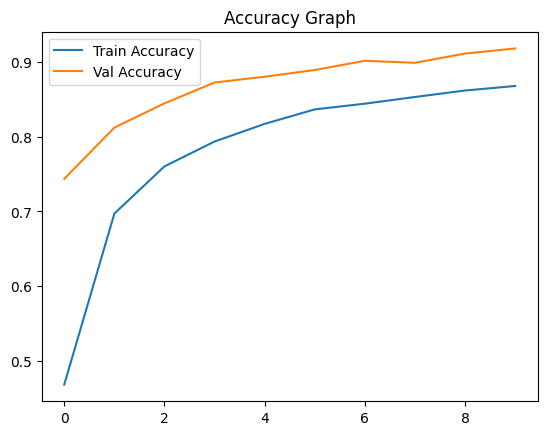

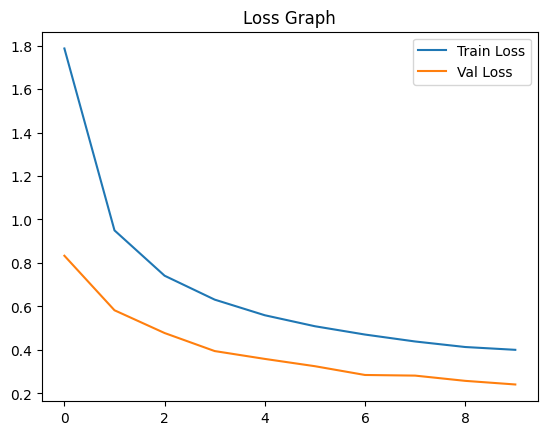

In [ ]:
import matplotlib.pyplot as plt

acc = history.history['accuracy']
val_acc = history.history['val_accuracy']

loss = history.history['loss']
val_loss = history.history['val_loss']

epochs_range = range(len(acc))

plt.figure()
plt.plot(epochs_range, acc, label='Train Accuracy')
plt.plot(epochs_range, val_acc, label='Val Accuracy')
plt.legend()
plt.title("Accuracy Graph")
plt.show()

plt.figure()
plt.plot(epochs_range, loss, label='Train Loss')
plt.plot(epochs_range, val_loss, label='Val Loss')
plt.legend()
plt.title("Loss Graph")
plt.show()

1/1 ━━━━━━━━━━━━━━━━━━━━ 3s 3s/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 155ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 150ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 133ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 125ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 130ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 130ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 132ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 121ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 120ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 110ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 110ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 107ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 112ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 109ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 102ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 107ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 105ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 111ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 105ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 105ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 107ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 106ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 114ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 103ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 

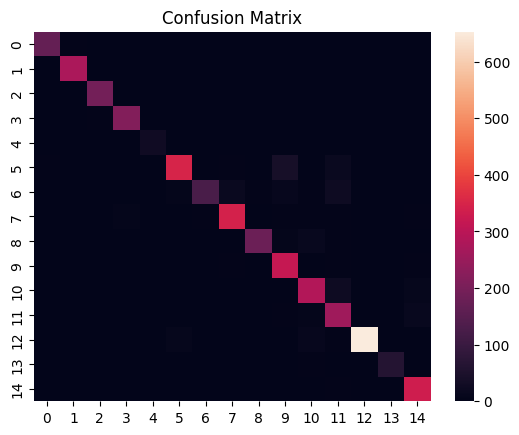

                                             precision    recall  f1-score   support

              Pepper__bell___Bacterial_spot       0.96      0.97      0.96       176
                     Pepper__bell___healthy       0.98      0.99      0.98       280
                      Potato___Early_blight       0.96      0.99      0.97       194
                       Potato___Late_blight       0.96      0.96      0.96       224
                           Potato___healthy       0.93      0.93      0.93        29
                      Tomato_Bacterial_spot       0.96      0.84      0.89       414
                        Tomato_Early_blight       0.94      0.62      0.75       200
                         Tomato_Late_blight       0.92      0.93      0.92       369
                           Tomato_Leaf_Mold       0.96      0.87      0.91       208
                  Tomato_Septoria_leaf_spot       0.82      0.94      0.88       337
Tomato_Spider_mites_Two_spotted_spider_mite       0.85      0.89

In [ ]:
import numpy as np
from sklearn.metrics import confusion_matrix, classification_report
import seaborn as sns

y_true = []
y_pred = []

for images, labels in val_ds:
    preds = model.predict(images)
    y_true.extend(labels.numpy())
    y_pred.extend(np.argmax(preds, axis=1))

cm = confusion_matrix(y_true, y_pred)

plt.figure()
sns.heatmap(cm, annot=False)
plt.title("Confusion Matrix")
plt.show()

print(classification_report(y_true, y_pred, target_names=class_names))

In [ ]:
base_model.trainable = True

model.compile(
    optimizer=tf.keras.optimizers.Adam(1e-5),
    loss='sparse_categorical_crossentropy',
    metrics=['accuracy']
)

history_fine = model.fit(
    train_ds,
    validation_data=val_ds,
    epochs=5
)

Epoch 1/5
516/516 ━━━━━━━━━━━━━━━━━━━━ 237s 384ms/step - accuracy: 0.6302 - loss: 1.1856 - val_accuracy: 0.8125 - val_loss: 0.5582
Epoch 2/5
516/516 ━━━━━━━━━━━━━━━━━━━━ 194s 376ms/step - accuracy: 0.7722 - loss: 0.7025 - val_accuracy: 0.8636 - val_loss: 0.4127
Epoch 3/5
516/516 ━━━━━━━━━━━━━━━━━━━━ 194s 376ms/step - accuracy: 0.8220 - loss: 0.5430 - val_accuracy: 0.8919 - val_loss: 0.3287
Epoch 4/5
516/516 ━━━━━━━━━━━━━━━━━━━━ 194s 376ms/step - accuracy: 0.8590 - loss: 0.4324 - val_accuracy: 0.9099 - val_loss: 0.2714
Epoch 5/5
516/516 ━━━━━━━━━━━━━━━━━━━━ 195s 377ms/step - accuracy: 0.8790 - loss: 0.3668 - val_accuracy: 0.9227 - val_loss: 0.2282


In [ ]:
acc = history.history['accuracy'] + history_fine.history['accuracy']
val_acc = history.history['val_accuracy'] + history_fine.history['val_accuracy']

loss = history.history['loss'] + history_fine.history['loss']
val_loss = history.history['val_loss'] + history_fine.history['val_loss']

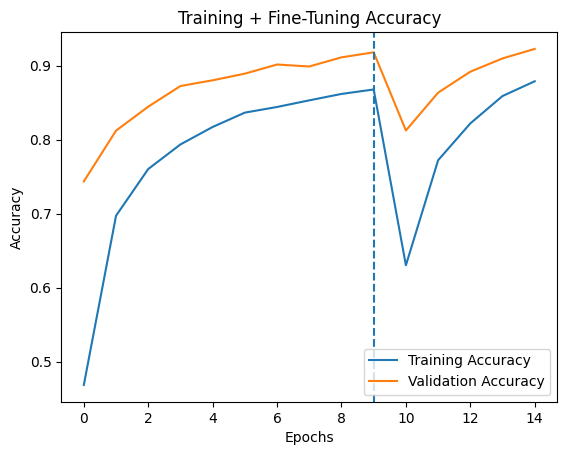

In [ ]:
import matplotlib.pyplot as plt

epochs_range = range(len(acc))

plt.figure()
plt.plot(epochs_range, acc, label='Training Accuracy')
plt.plot(epochs_range, val_acc, label='Validation Accuracy')
plt.axvline(x=len(history.history['accuracy'])-1, linestyle='--')  # shows where fine-tuning starts
plt.legend()
plt.title('Training + Fine-Tuning Accuracy')
plt.xlabel('Epochs')
plt.ylabel('Accuracy')
plt.show()

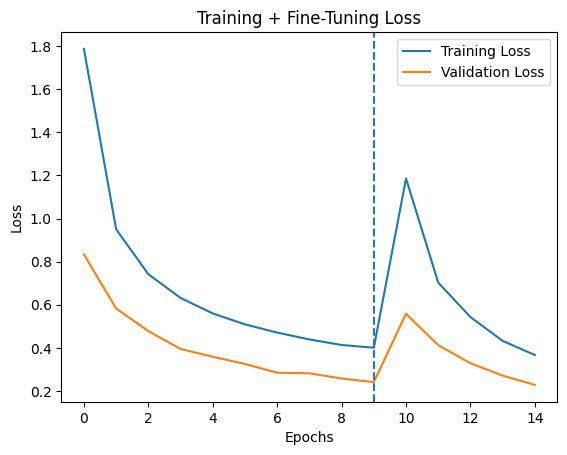

In [ ]:
plt.figure()
plt.plot(epochs_range, loss, label='Training Loss')
plt.plot(epochs_range, val_loss, label='Validation Loss')
plt.axvline(x=len(history.history['loss'])-1, linestyle='--')
plt.legend()
plt.title('Training + Fine-Tuning Loss')
plt.xlabel('Epochs')
plt.ylabel('Loss')
plt.show()

In [ ]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [ ]:
import os

SAVE_PATH = '/content/drive/MyDrive/crop_disease_project/'

os.makedirs(SAVE_PATH, exist_ok=True)

print("Folder created at:", SAVE_PATH)

Folder created at: /content/drive/MyDrive/crop_disease_project/


In [ ]:
model.save(SAVE_PATH + 'model.keras')

In [ ]:
import json

with open(SAVE_PATH + 'class_names.json', 'w') as f:
    json.dump(class_names, f)

In [ ]:
history_data = {
    'accuracy': acc,
    'val_accuracy': val_acc,
    'loss': loss,
    'val_loss': val_loss
}

with open(SAVE_PATH + 'history.json', 'w') as f:
    json.dump(history_data, f)

In [ ]:
import matplotlib.pyplot as plt

epochs_range = range(len(acc))

# Accuracy Graph
plt.figure()
plt.plot(epochs_range, acc, label='Train Accuracy')
plt.plot(epochs_range, val_acc, label='Val Accuracy')
plt.legend()
plt.title('Accuracy')
plt.savefig(SAVE_PATH + 'accuracy_plot.png')
plt.close()

# Loss Graph
plt.figure()
plt.plot(epochs_range, loss, label='Train Loss')
plt.plot(epochs_range, val_loss, label='Val Loss')
plt.legend()
plt.title('Loss')
plt.savefig(SAVE_PATH + 'loss_plot.png')
plt.close()

In [ ]:
from sklearn.metrics import classification_report, confusion_matrix
import numpy as np

y_true = []
y_pred = []

for images, labels in val_ds:
    preds = model.predict(images)
    y_true.extend(labels.numpy())
    y_pred.extend(np.argmax(preds, axis=1))

# Save classification report
report = classification_report(y_true, y_pred)

with open(SAVE_PATH + 'classification_report.txt', 'w') as f:
    f.write(report)

# Save confusion matrix
cm = confusion_matrix(y_true, y_pred)
np.save(SAVE_PATH + 'confusion_matrix.npy', cm)

In [ ]:
!ls /content/drive/MyDrive/crop_disease_project/

accuracy_plot.png	   class_names.json	 history.json	model.keras
classification_report.txt  confusion_matrix.npy  loss_plot.png


In [ ]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [ ]:
import tensorflow as tf
import json

SAVE_PATH = '/content/drive/MyDrive/crop_disease_project/'

# Load model
model = tf.keras.models.load_model(SAVE_PATH + 'model.keras')

# Load class names
with open(SAVE_PATH + 'class_names.json', 'r') as f:
    class_names = json.load(f)

In [ ]:
from google.colab import files
uploaded = files.upload()

In [ ]:
img_path = list(uploaded.keys())[0]
print("Using image:", img_path)

Using image: potato early blight.jpg


In [ ]:
from tensorflow.keras.preprocessing import image
from tensorflow.keras.applications.efficientnet import preprocess_input
import numpy as np

IMG_SIZE = (224, 224)

img = image.load_img(img_path, target_size=IMG_SIZE)
img_array = image.img_to_array(img)

# Correct preprocessing
img_array = preprocess_input(img_array)

img_array = np.expand_dims(img_array, axis=0)



In [ ]:
predictions = model.predict(img_array)

predicted_class = class_names[np.argmax(predictions)]
confidence = np.max(predictions)

print("Predicted Disease:", predicted_class)
print("Confidence:", confidence)

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 104ms/step
Predicted Disease: Potato___Early_blight
Confidence: 0.98408645


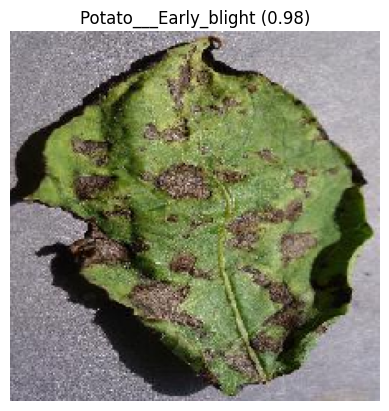

In [ ]:
import matplotlib.pyplot as plt

plt.imshow(img)
plt.title(f"{predicted_class} ({confidence:.2f})")
plt.axis('off')
plt.show()

In [ ]:
top3 = np.argsort(predictions[0])[-3:][::-1]

print("\nTop 3 Predictions:")
for i in top3:
    print(f"{class_names[i]}: {predictions[0][i]:.3f}")


Top 3 Predictions:
Tomato_Late_blight: 0.998
Potato___Late_blight: 0.002
Tomato_Early_blight: 0.000
